# K-Nearest Neighbors (KNN) From Scratch

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Loading the Dataset

In [2]:
df = pd.read_csv("data.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Data Exploration

In [3]:
df.shape

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.select_dtypes(include='object').columns

Index(['diagnosis'], dtype='object')

In [6]:
df.select_dtypes(include=('int', 'float')).columns

Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [7]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
204,87930,B,12.47,18.60,81.09,481.9,0.09965,0.1058,0.08005,0.03821,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750,NaN
70,859575,M,18.94,21.31,123.60,1130.0,0.09009,0.1029,0.10800,0.07951,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589,NaN
131,8670,M,15.46,19.48,101.70,748.9,0.10920,0.1223,0.14660,0.08087,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019,NaN
431,907915,B,12.40,17.68,81.47,467.8,0.10540,0.1316,0.07741,0.02799,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359,NaN
540,921385,B,11.54,14.44,74.65,402.9,0.09984,0.1120,0.06737,0.02594,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,NaN


## Data Preprocessing

**Dropping irrelevant columns**

`id` carries no predictive information, and `Unnamed: 32` is an empty artifact column from the CSV export.

In [8]:
df = df.drop(columns=["id", "Unnamed: 32"], errors='ignore')
df.sample(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
243,B,13.750,23.77,88.54,590.0,0.08043,0.06807,0.046970,0.023440,0.1773,...,15.01,26.34,98.00,706.0,0.09368,0.14420,0.13590,0.06106,0.2663,0.06321
101,B,6.981,13.43,43.79,143.5,0.11700,0.07568,0.000000,0.000000,0.1930,...,7.93,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382
230,M,17.050,19.08,113.40,895.0,0.11410,0.15720,0.191000,0.109000,0.2131,...,19.59,24.89,133.50,1189.0,0.17030,0.39340,0.50180,0.25430,0.3109,0.09061
269,B,10.710,20.39,69.50,344.9,0.10820,0.12890,0.084480,0.028670,0.1668,...,11.69,25.21,76.51,410.4,0.13350,0.25500,0.25340,0.08600,0.2605,0.08701
522,B,11.260,19.83,71.30,388.1,0.08511,0.04413,0.005067,0.005664,0.1637,...,11.93,26.43,76.38,435.9,0.11080,0.07723,0.02533,0.02832,0.2557,0.07613


**Checking for missing values**

In [9]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


**Handling missing values (if any were found above)**

In [10]:
if df.isnull().sum().sum() > 0:
    before = df.shape[0]
    df = df.dropna()
    print(f"Removed {before - df.shape[0]} rows containing missing values.")
    print(f"New shape: {df.shape}")
else:
    print("No missing values found. No action needed.")

No missing values found. No action needed.


**Checking for duplicate rows**

In [11]:
df.duplicated().sum()

np.int64(0)

**Handling duplicate rows (if any were found above)**

In [12]:
n_duplicates = df.duplicated().sum()

if n_duplicates > 0:
    before = df.shape[0]
    df = df.drop_duplicates()
    print(f"Removed {before - df.shape[0]} duplicate rows.")
    print(f"New shape: {df.shape}")
else:
    print("No duplicate rows found. No action needed.")

No duplicate rows found. No action needed.


**Encoding the target column**

`diagnosis` is Malignant/Benign as text, so we map it to 1/0 for the model.

In [13]:
df["diagnosis"] = df["diagnosis"].map({'M': 1, 'B': 0})
df["diagnosis"].sample(5)

,diagnosis
482,0
65,1
550,0
481,0
23,1


**Separating features and target**

In [14]:
x = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [15]:
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Train / Test Split**

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Data Analysis

**Target class distribution**

diagnosis
0    357
1    212
Name: count, dtype: int64


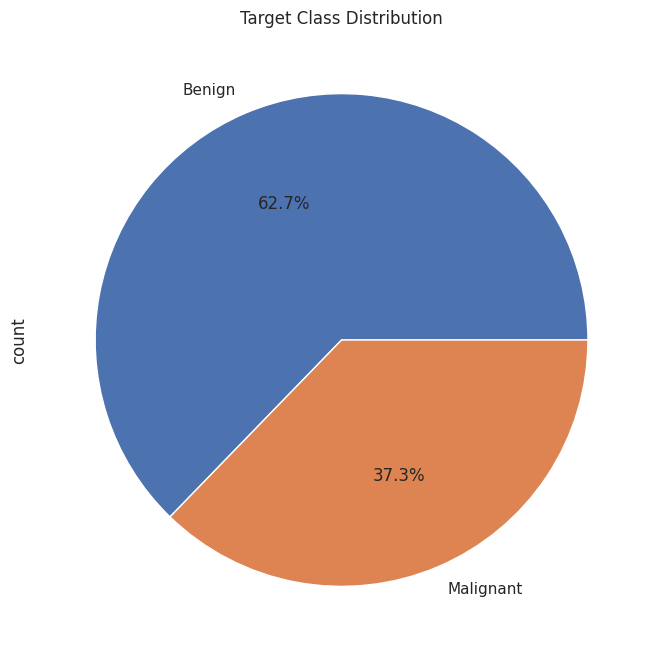

In [17]:
value_counts = y.value_counts()
print(value_counts)
plt.figure(figsize=(8, 8))
value_counts.plot.pie(autopct='%1.1f%%', labels=['Benign', 'Malignant'])
plt.title('Target Class Distribution')
plt.show()

**Correlation heatmap**

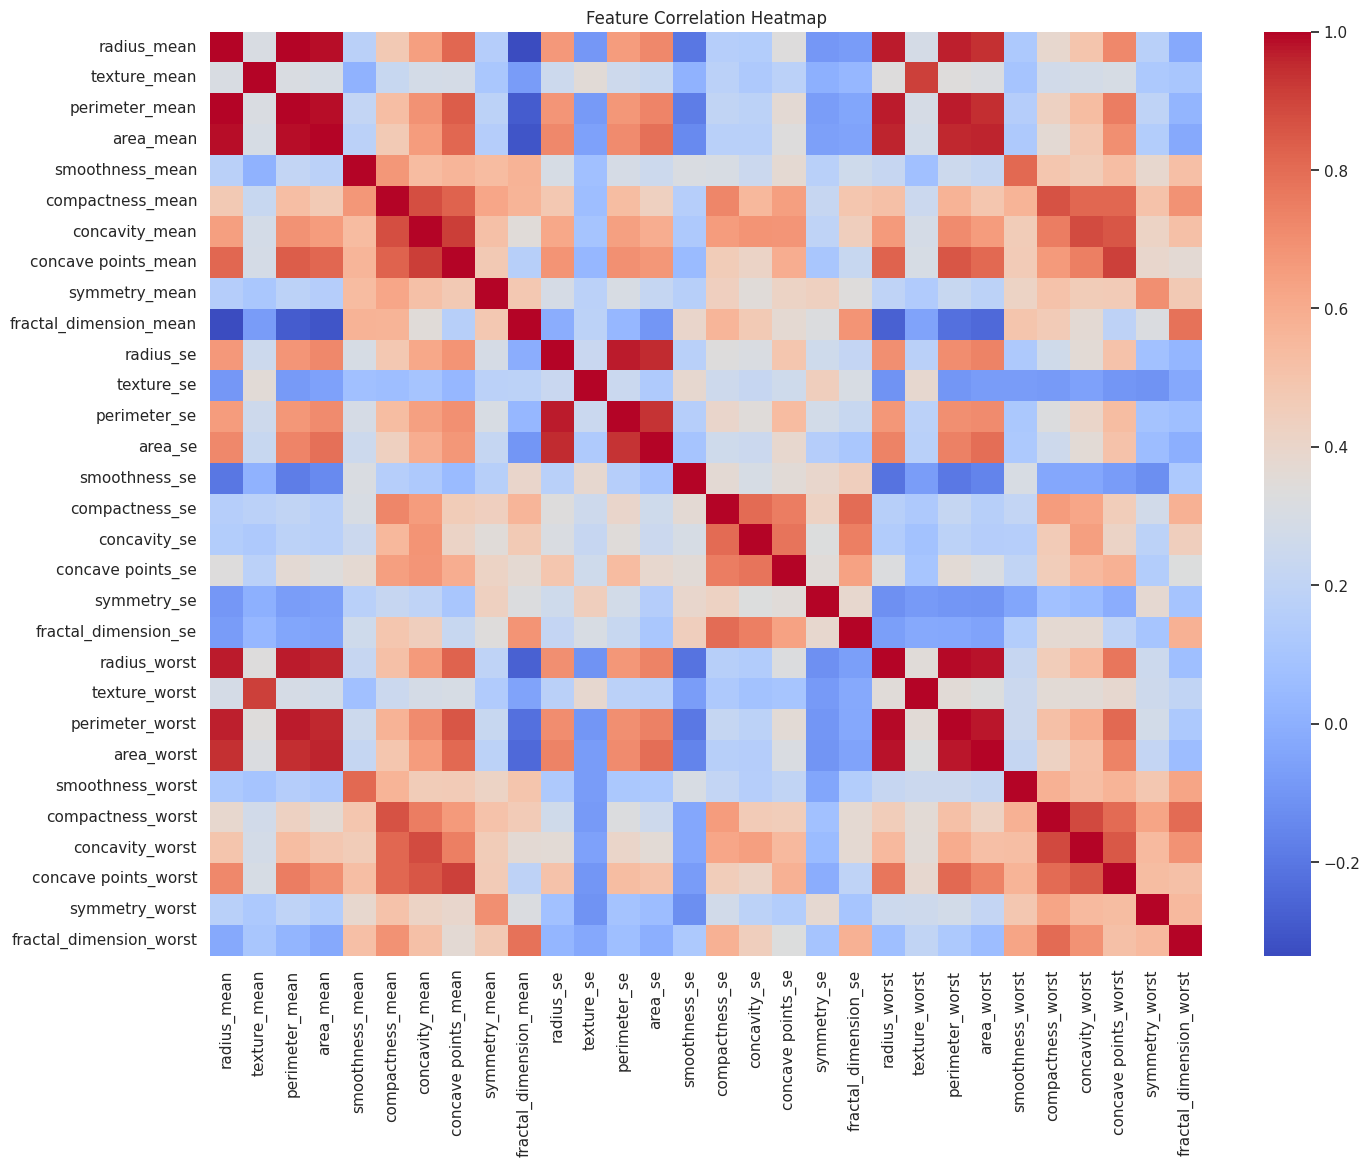

In [18]:
plt.figure(figsize=(16, 12))
sns.heatmap(x_train.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Function to detect highly correlated features**

Removes the first feature of any pair whose correlation exceeds the given threshold.

In [19]:
def correlation(dataframe, threshold):
    col_corr = set()  # names of correlated columns
    corr_matrix = dataframe.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

**Applying the function and dropping the flagged features (if any)**

In [20]:
corr_features = correlation(x_train, 0.9)
print(f"Highly correlated features to drop: {corr_features}")

if corr_features:
    x_train = x_train.drop(columns=corr_features)
    x_test = x_test.drop(columns=corr_features)
    print(f"Dropped {len(corr_features)} feature(s). New shape: {x_train.shape}")
else:
    print("No highly correlated features found. No action needed.")

x_train.head()

Highly correlated features to drop: {'area_se', 'texture_worst', 'concave points_worst', 'area_mean', 'perimeter_worst', 'area_worst', 'concave points_mean', 'perimeter_se', 'perimeter_mean', 'radius_worst'}
Dropped 10 feature(s). New shape: (455, 20)


,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,0.10660,0.14130,0.31300,0.2111,0.08046,0.3274,1.1940,0.009549,0.08606,0.303800,0.033220,0.04197,0.009559,0.14820,0.43650,1.25200,0.4228,0.11750
181,21.090,26.57,0.11410,0.28320,0.24870,0.2395,0.07398,0.6298,0.7629,0.004253,0.04759,0.038720,0.015670,0.01798,0.005295,0.14910,0.75840,0.67800,0.4098,0.12840
63,9.173,13.86,0.07721,0.08751,0.05988,0.2341,0.06963,0.4098,2.2650,0.008738,0.03938,0.043120,0.015600,0.04192,0.005822,0.09836,0.16780,0.13970,0.3282,0.08490
248,10.650,25.22,0.09657,0.07234,0.02379,0.1897,0.06329,0.2497,1.4930,0.007189,0.01035,0.010810,0.006245,0.02158,0.002619,0.14990,0.13980,0.11250,0.3409,0.08147
60,10.170,14.88,0.11340,0.08061,0.01084,0.2743,0.06960,0.5158,1.4410,0.007514,0.01099,0.007665,0.008193,0.04183,0.005953,0.12750,0.09866,0.02168,0.3557,0.08020


**Converting to arrays**

Our from-scratch classes work directly with NumPy arrays.

In [21]:
x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

## Standardization — Implemented From Scratch

Standardizes features to zero mean and unit variance, fitting only on the training set to avoid data leakage.

In [22]:
class StandardScalerFromScratch:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1e-8  # avoid division by zero for constant columns
        return self

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

**Applying the scaler**

In [23]:
scaler = StandardScalerFromScratch()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [24]:
x_train[:5]

array([[-1.44075296, -0.43531947,  0.78057331,  0.71892128,  2.82313451,
         1.09266219,  2.45817261, -0.26380039, -0.01605246,  0.83836493,
         3.25102691,  8.43893667,  3.39198733,  2.62116574,  2.06120787,
         0.72289445,  1.18673232,  4.67282796,  2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  1.319843  ,  3.42627493,  2.01311199,
         2.1270036 ,  1.55839569,  0.80531919, -0.81268678, -0.89605315,
         1.18122247,  0.18362761,  0.60059598, -0.31771686,  0.52963649,
         0.76192793,  3.26560084,  1.92862053,  1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.33264483, -0.30735463, -0.36555756,
         1.93033305,  0.95437877,  0.02752055,  1.96305996,  0.57276579,
         0.7394992 ,  0.32065553,  0.58946222,  2.61504052,  0.71892779,
        -1.43869328, -0.54856427, -0.64491059,  0.59760192,  0.0578942 ],
       [-0.98179678,  1.41622208,  0.05938999, -0.59678772, -0.82020317,
         0.31326409,  0.07404147, -0.53850473,  

## KNN Algorithm — Implemented From Scratch

For each test point, computes the Euclidean distance to every training point, finds the `k` nearest neighbors, and predicts by majority vote.

In [25]:
class KNNFromScratch:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _calculate_distance(self, test_point):
        squared_diff = np.square(self.X_train - test_point)
        sum_squared_diff = np.sum(squared_diff, axis=1)
        return np.sqrt(sum_squared_diff)

    def _predict_single(self, test_point):
        distances = self._calculate_distance(test_point)

        nearest_indices = np.argsort(distances)[:self.k]
        nearest_labels = self.y_train[nearest_indices]

        votes = np.bincount(nearest_labels)
        return np.argmax(votes)

    def predict(self, X_test):
        return np.array([self._predict_single(x) for x in X_test])

## Training the Model

In [26]:
knn = KNNFromScratch(k=5)
knn.fit(x_train, y_train)

## Model Evaluation

In [27]:
y_pred = knn.predict(x_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Chosen K value: {knn.k}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Chosen K value: 5
Test Accuracy: 0.9211
Test F1 Score: 0.9209


## Visualization

**Confusion matrix**

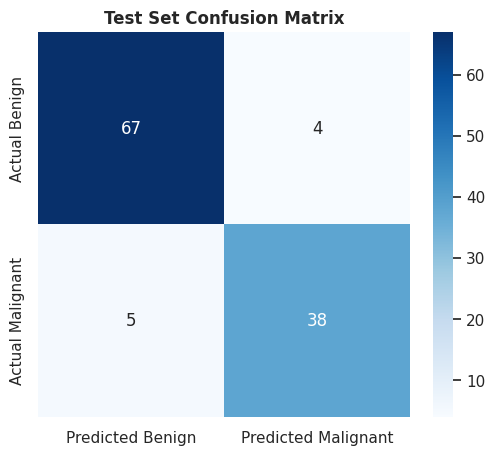

In [28]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Test Set Confusion Matrix', fontweight='bold')
plt.show()